In [4]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

[0]	train-rmse:0.97942	val-rmse:3.82704
[20]	train-rmse:0.65015	val-rmse:2.94382
[40]	train-rmse:0.53962	val-rmse:2.60950
[60]	train-rmse:0.50033	val-rmse:2.49932
[80]	train-rmse:0.48066	val-rmse:2.46060
[100]	train-rmse:0.46462	val-rmse:2.45036
[120]	train-rmse:0.45335	val-rmse:2.44609
[130]	train-rmse:0.44862	val-rmse:2.44862


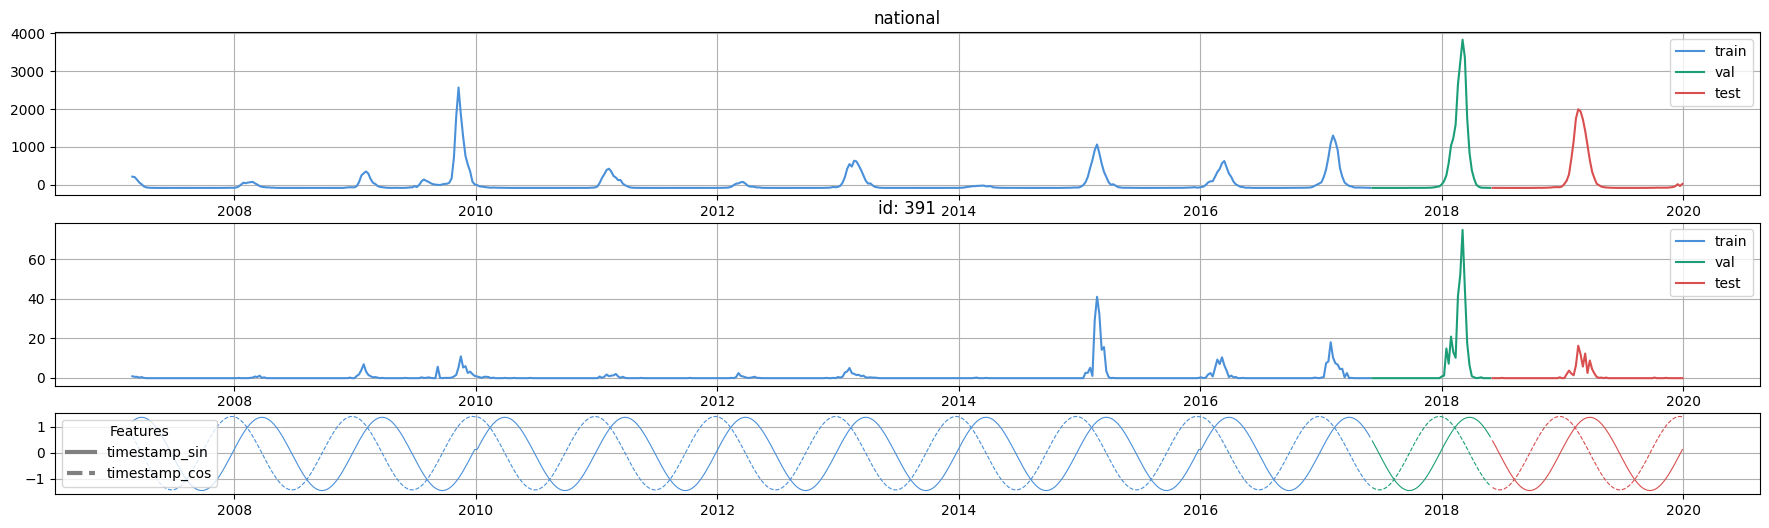

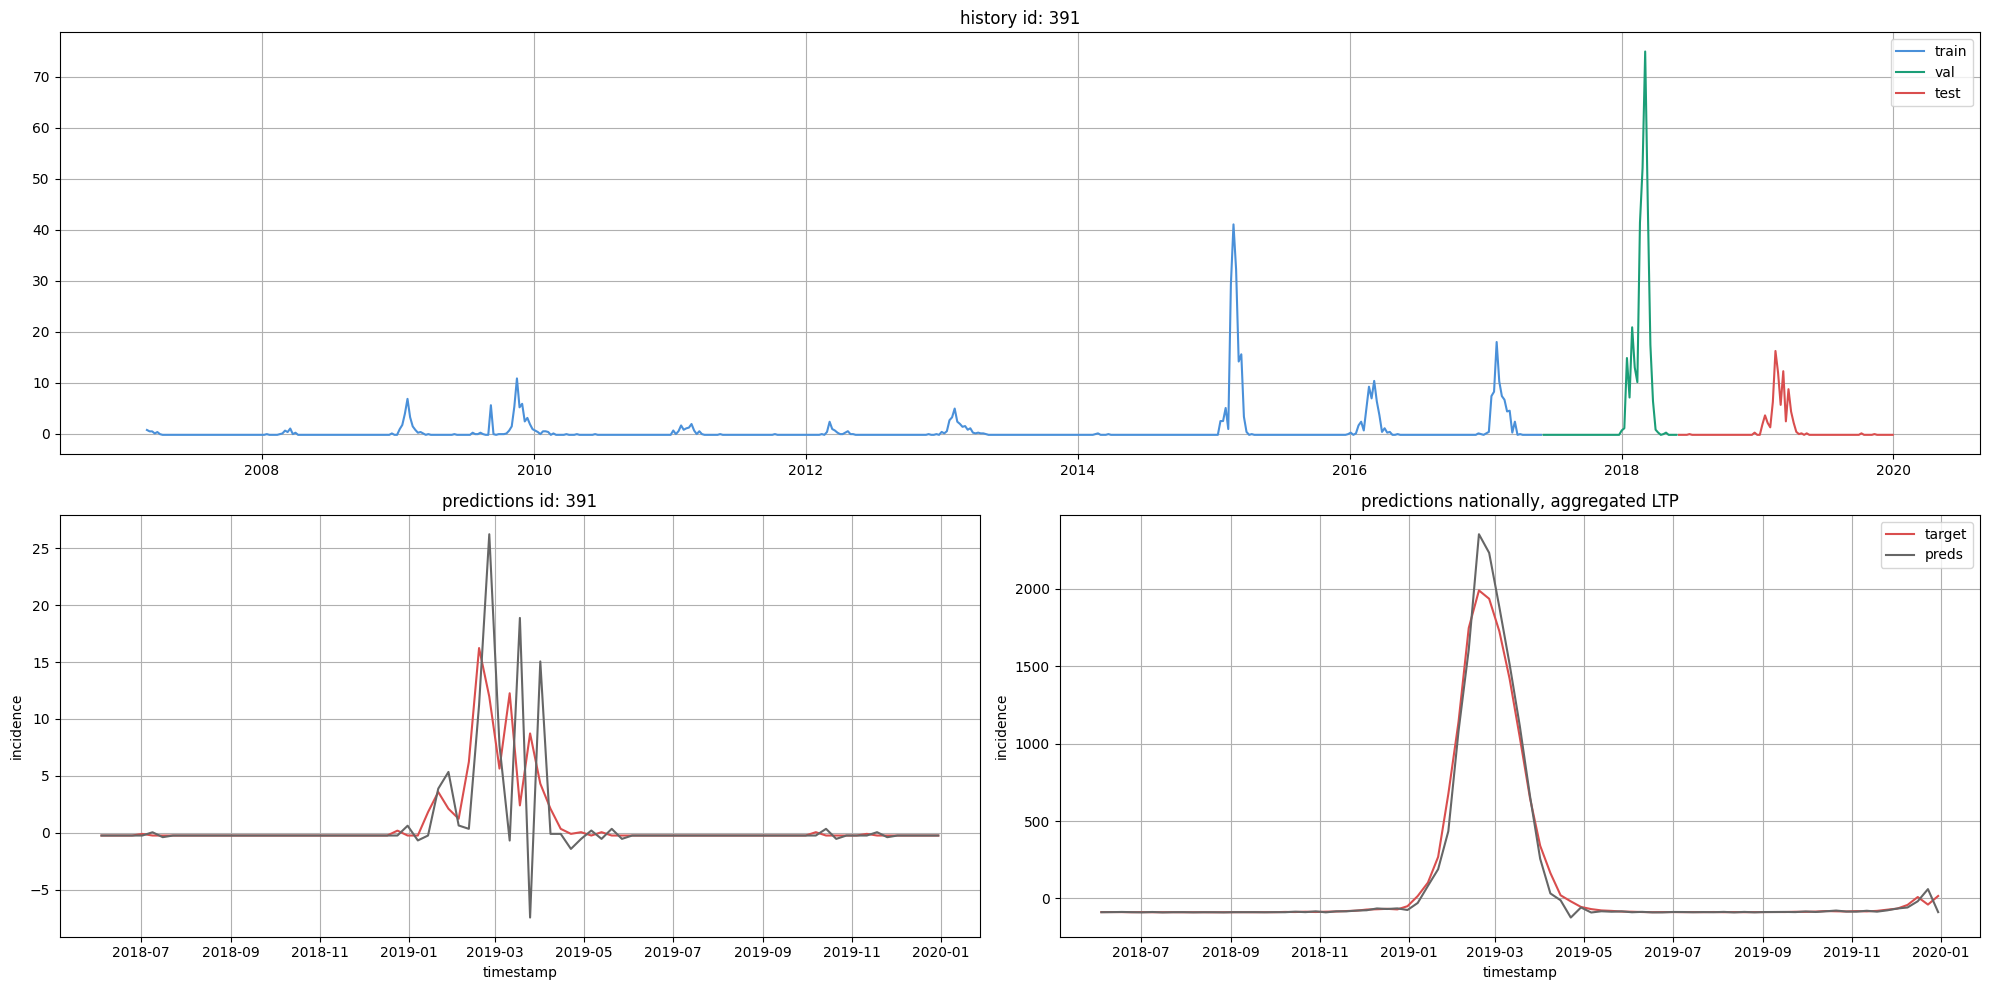

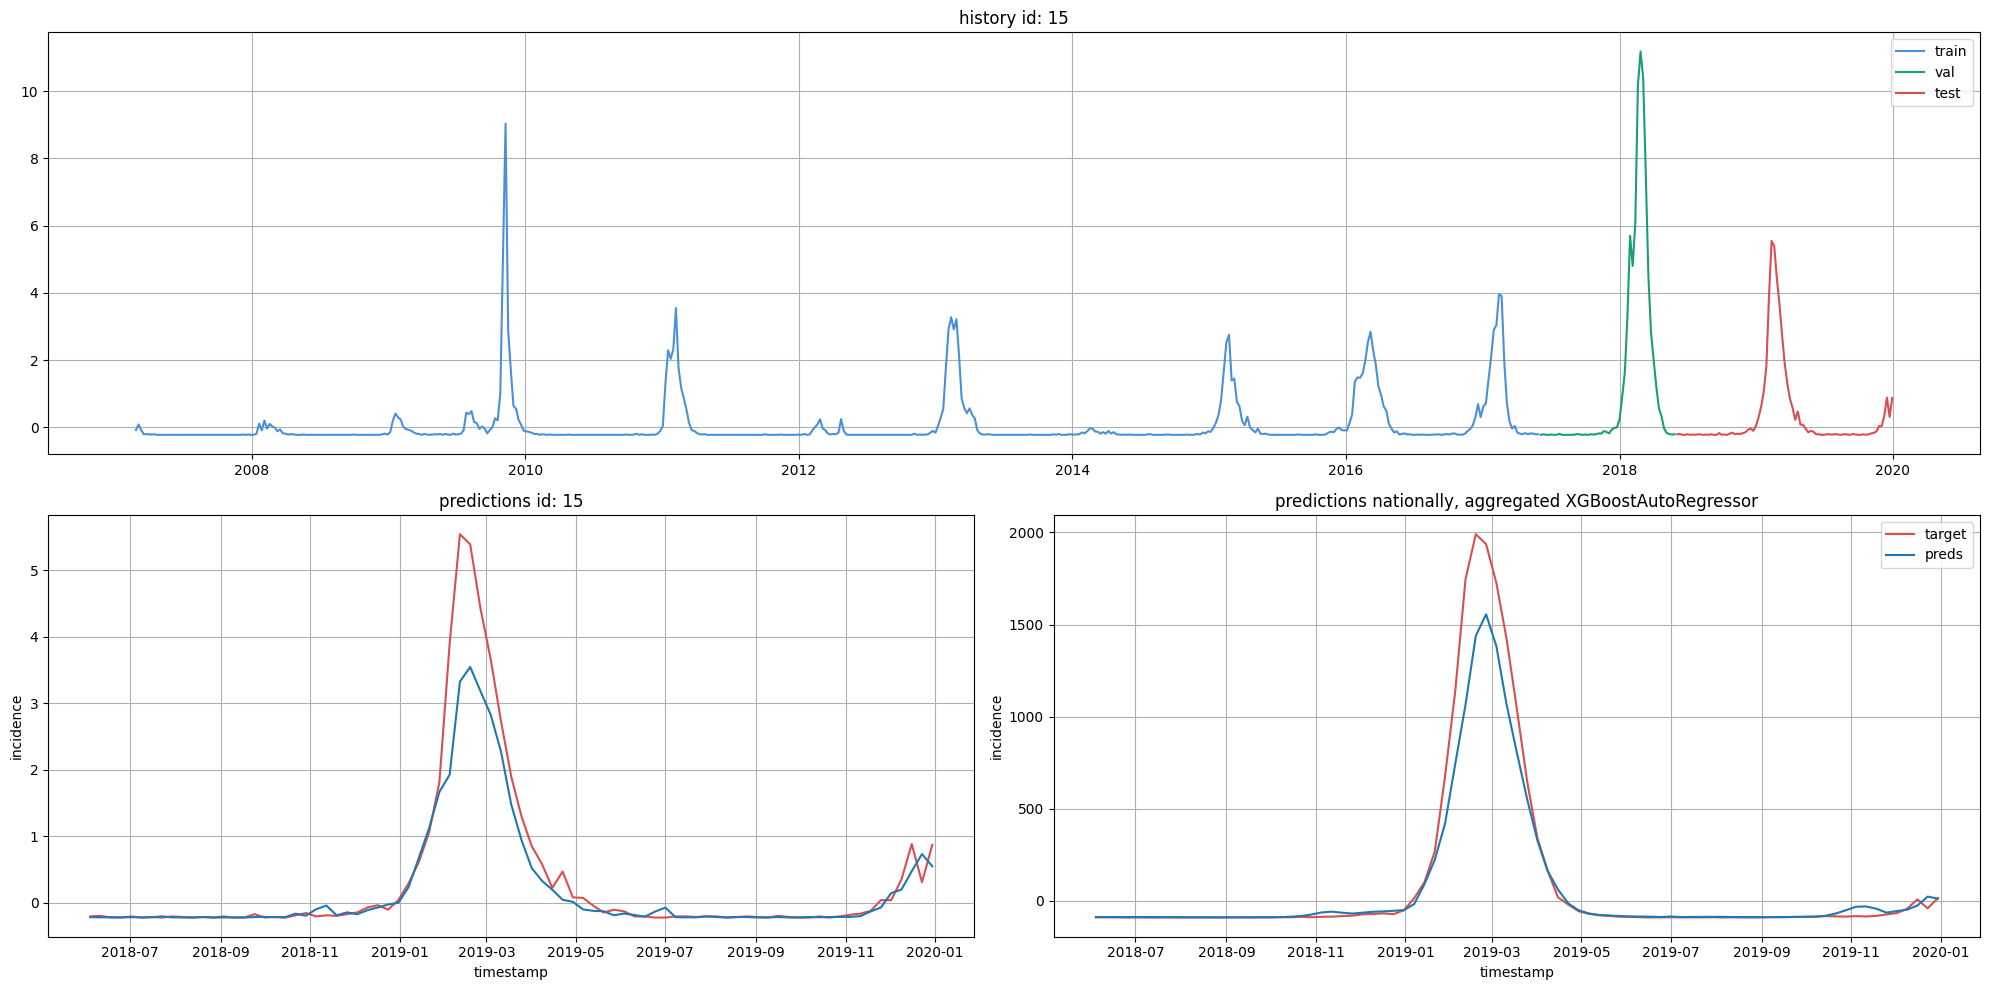

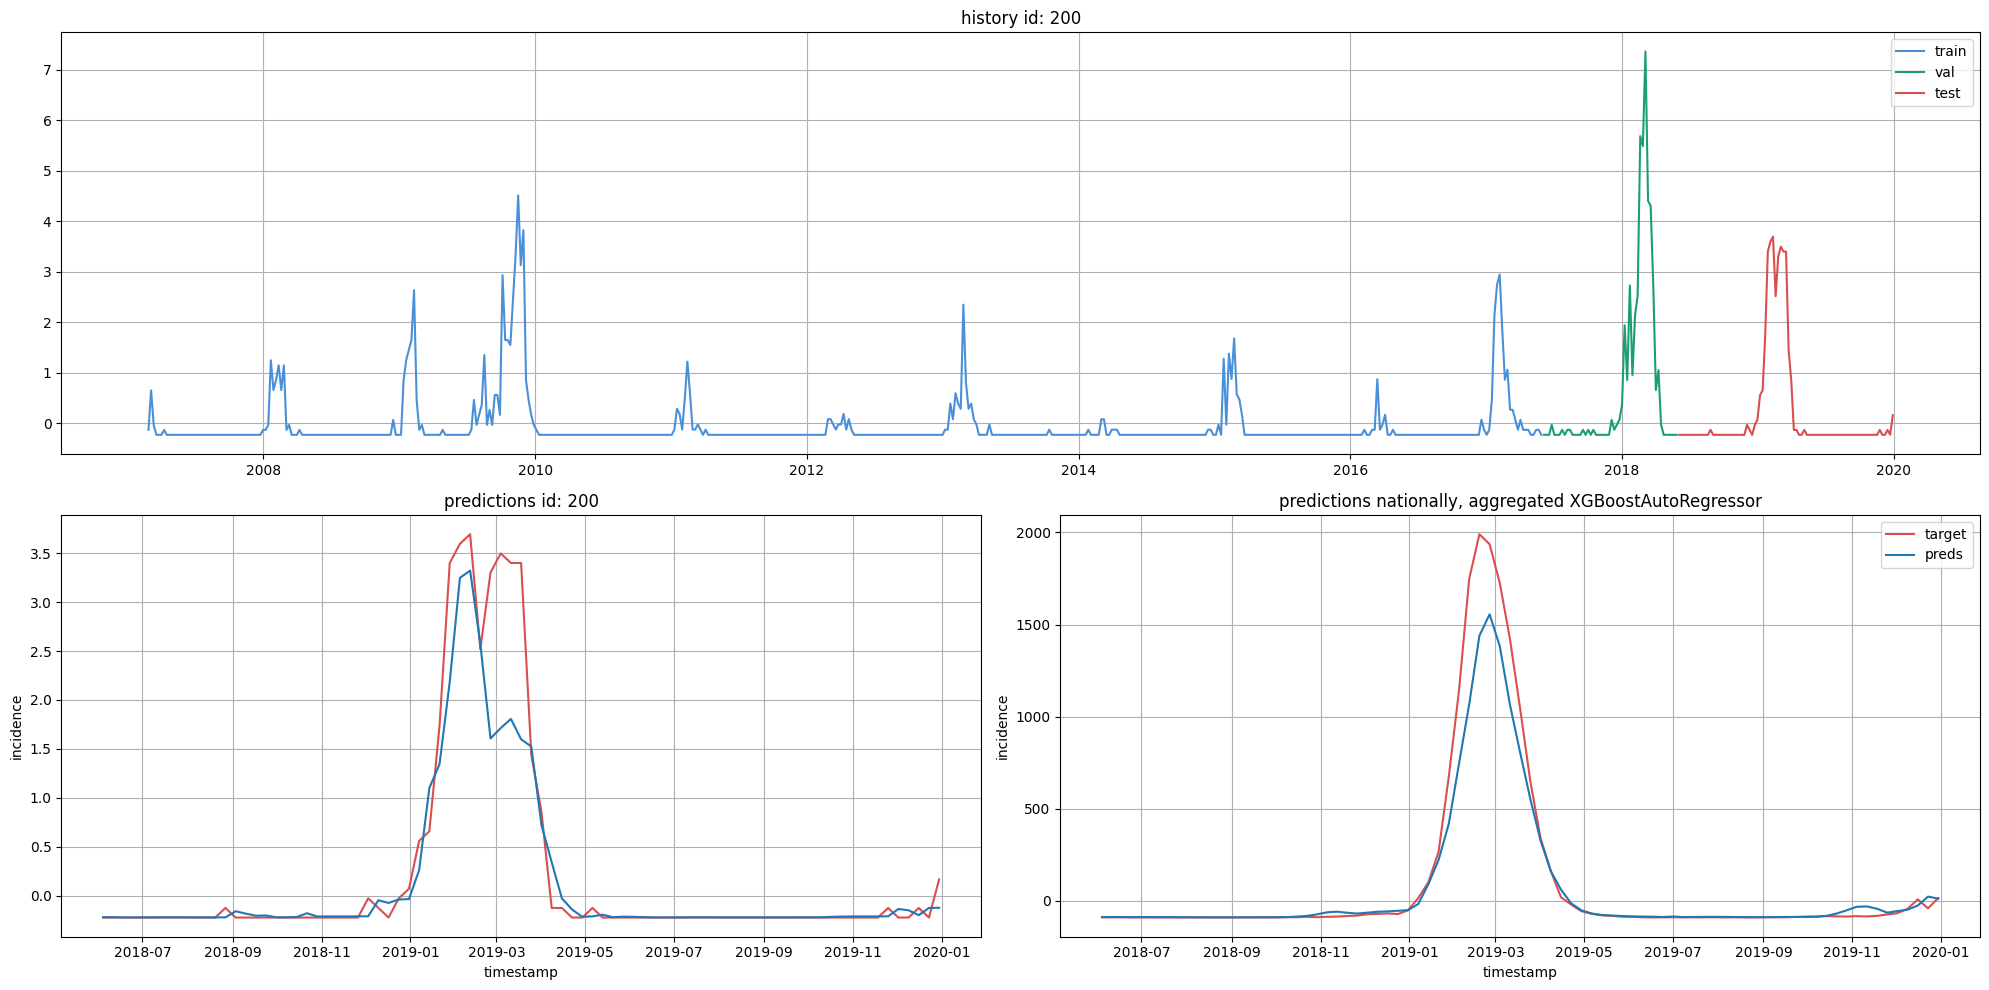

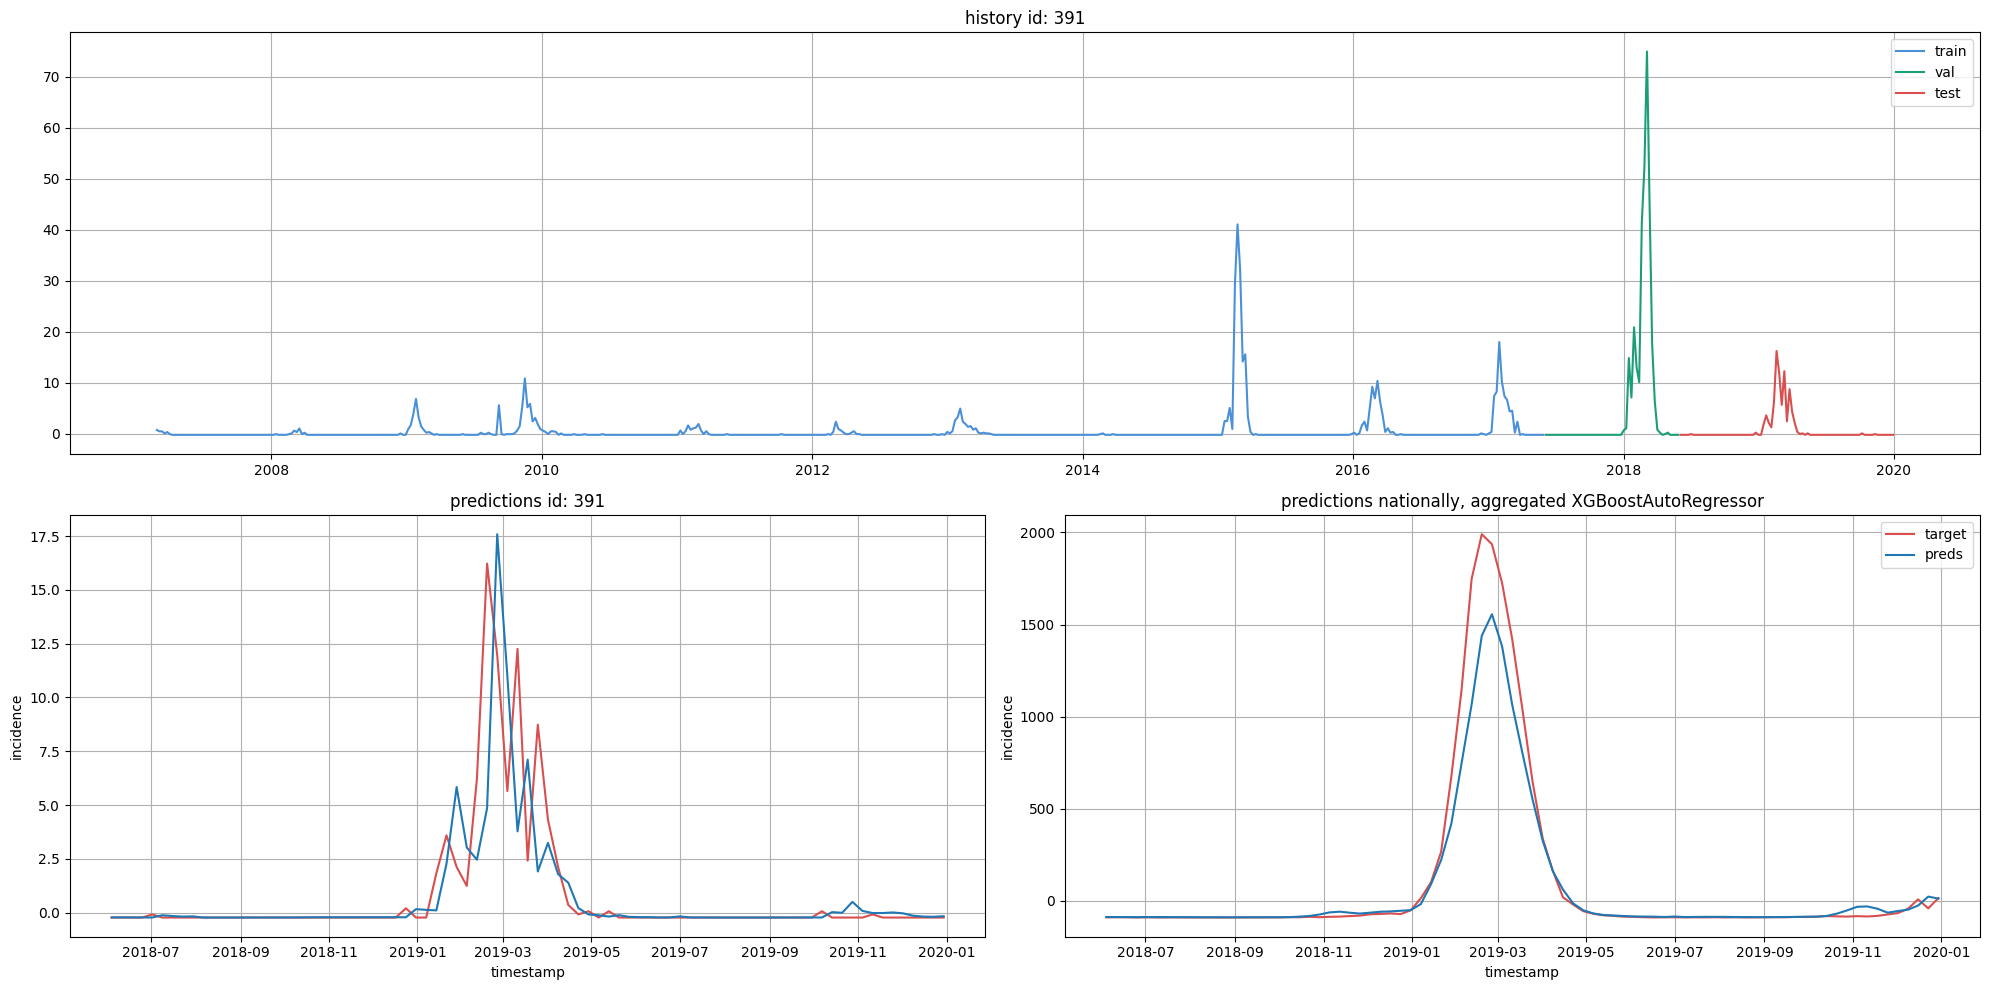

In [11]:
epidata_lag1 = EpiDataLoader(disease_name = 'influenza', min_date = ' 2007-01-01', data_env_dir = data_env, max_date = '2020-01-01')
epidata_lag1.add_time_features()
epidata_lag1.normalize('2017-06-01','2018-06-01', method = 'zscore')
epidata_lag1.add_lagged_features(lags = range(1,9))
epidata_lag1.split_data()
epidata_lag1.preview()

from src.models.localtrendpredictor import LocalTrendPredictor

dataloader_copy = epidata_lag1.copy()

ltp = LocalTrendPredictor(dataloader_copy)
ltp.forecast()
ltp.show_forecasts(391)

from src.models import XGBoostAutoRegressor

xgb_model = XGBoostAutoRegressor(epidata_lag1)
xgb_model.forecast()
xgb_model.show_forecasts(15)
xgb_model.show_forecasts(200)
xgb_model.show_forecasts(391)